# Credit Risk Prediction Using Machine Learning

## 1. Problem Statement

Credit risk assessment is an important task for banks and financial institutions. Before approving a loan, lenders need to understand whether an applicant is likely to repay the loan or become a risky borrower.

The objective of this project is to build a machine learning model that predicts whether a loan applicant is risky or not based on features such as age, income, employment length, loan amount, interest rate, loan purpose, previous default history, and credit history length.

This is a binary classification problem where the target variable is `Status`.

- `Status = 0` means the applicant is not risky.
- `Status = 1` means the applicant is risky.

The final model can help financial institutions make better loan approval decisions and reduce the chances of financial loss.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


In [2]:
df = pd.read_csv('credit_risk.csv')
df.head()

,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3
1,1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2
2,2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3
3,3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2
4,4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4


## 2. Dataset Overview

The dataset contains information about loan applicants and their financial background. Each row represents one loan applicant, and the columns describe the applicant's personal, employment, loan, and credit-related details.

The main objective is to use these features to predict the applicant's loan risk status.

The target column for this project is `Status`.

In [3]:
df.shape

(32581, 12)

In [4]:
df.columns

Index(['Id', 'Age', 'Income', 'Home', 'Emp_length', 'Intent', 'Amount', 'Rate',
       'Status', 'Percent_income', 'Default', 'Cred_length'],
      dtype='str')

### Column Description

| Column | Description |
|---|---|
| `Age` | Age of the loan applicant |
| `Income` | Annual income of the applicant |
| `Home` | Home ownership status |
| `Emp_length` | Employment length of the applicant |
| `Intent` | Purpose of the loan |
| `Amount` | Loan amount requested |
| `Rate` | Interest rate of the loan |
| `Status` | Target variable indicating loan risk |
| `Percent_income` | Loan amount as a percentage of income |
| `Default` | Previous loan default history, indicating whether the applicant has failed to repay a loan before |
| `Cred_length` | Credit history length |

## 3. Data Inspection

In this section, the dataset is inspected to understand its structure, data types, missing values, duplicate records, and basic statistical properties.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              32581 non-null  int64  
 1   Age             32581 non-null  int64  
 2   Income          32581 non-null  int64  
 3   Home            32581 non-null  str    
 4   Emp_length      31686 non-null  float64
 5   Intent          32581 non-null  str    
 6   Amount          32581 non-null  int64  
 7   Rate            29465 non-null  float64
 8   Status          32581 non-null  int64  
 9   Percent_income  32581 non-null  float64
 10  Default         32581 non-null  str    
 11  Cred_length     32581 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 3.5 MB


In [6]:
df.describe()

,Id,Age,Income,Emp_length,Amount,Rate,Status,Percent_income,Cred_length
count,32581.000000,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,16290.006139,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,9405.479594,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,0.000000,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,8145.000000,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,16290.000000,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,24435.000000,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,32780.000000,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


The summary statistics show possible outliers in some numerical columns. For example, the maximum values of `Age` and `Emp_length` are much higher than their 75th percentile values. This suggests that these columns may contain unrealistic or extreme values that need further investigation during data cleaning.

In [7]:
df.isna().sum()

Id                   0
Age                  0
Income               0
Home                 0
Emp_length         895
Intent               0
Amount               0
Rate              3116
Status               0
Percent_income       0
Default              0
Cred_length          0
dtype: int64

In [8]:
missing_values = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})
missing_values[missing_values["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Emp_length,895,2.747000
Rate,3116,9.563856


The missing value check shows that `Emp_length` and `Rate` contain missing values. These missing values should be handled before model training.

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Status"].value_counts()

Status
0    25473
1     7108
Name: count, dtype: int64

In [11]:
df["Status"].value_counts(normalize=True) * 100

Status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

The target variable distribution shows that the dataset is imbalanced. The number of non-risky applicants is higher than risky applicants.

Because of this imbalance, accuracy alone will not be enough to evaluate the model. Metrics such as precision, recall, F1-score, confusion matrix, and ROC-AUC should also be used.

## 4. Data Cleaning
In this section, data quality issues such as unnecessary columns, unrealistic values, and missing values are handled before exploratory data analysis and model building.

In [12]:
df= df.drop("Id", axis=1)

The `Id` column is a unique identifier for each applicant. Since it does not provide useful information for risk prediction, it was removed from the dataset before EDA and model building.

In [13]:
df.columns

Index(['Age', 'Income', 'Home', 'Emp_length', 'Intent', 'Amount', 'Rate',
       'Status', 'Percent_income', 'Default', 'Cred_length'],
      dtype='str')

In [14]:
df[df["Age"] > 100]

,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
81,144,250000,RENT,4.0,VENTURE,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,5000,12.73,0,0.00,N,25


In [15]:
df[df["Emp_length"] > 60]

,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,20000,6.54,0,0.10,N,4


The `Age` and `Emp_length` columns contain unrealistic maximum values. Since values such as age above 100 and employment length above 60 years are not reasonable for normal loan applicants, these records are treated as unrealistic values.

In [16]:
df = df[(df["Age"] <= 100) | (df["Age"].isnull())]
df = df[(df["Emp_length"] <= 60) | (df["Emp_length"].isnull())]

In [17]:
df[["Age", "Emp_length"]].describe()

,Age,Emp_length
count,32574.000000,31679.000000
mean,27.718426,4.782064
std,6.204987,4.034948
min,20.000000,0.000000
25%,23.000000,2.000000
50%,26.000000,4.000000
75%,30.000000,7.000000
max,94.000000,41.000000


Rows with clearly unrealistic values were removed from the dataset. Age values above 100 and employment length values above 60 years were considered unrealistic for normal loan applicants. Missing values were preserved at this step because they are handled separately using imputation.

In [18]:
df['Emp_length']= df['Emp_length'].fillna(df['Emp_length'].median())
df["Rate"] = df["Rate"].fillna(df["Rate"].median())

In [19]:
df.isna().sum()

Age               0
Income            0
Home              0
Emp_length        0
Intent            0
Amount            0
Rate              0
Status            0
Percent_income    0
Default           0
Cred_length       0
dtype: int64

Missing values in `Emp_length` and `Rate` were filled using the median value. Median imputation was used because these numerical columns may contain outliers, and the median is less affected by extreme values than the mean.

## 5. Exploratory Data Analysis (EDA)

In this section, visual analysis is performed to understand the patterns in the dataset and how different features are related to loan risk status.

### EDA Questions

1. What is the distribution of risky and non-risky applicants?
2. How are numerical features such as income, loan amount, and interest rate distributed?
3. Does interest rate differ between risky and non-risky applicants?
4. Does loan amount as a percentage of income affect loan risk?
5. Does previous default history affect loan risk?
6. Which loan purposes have higher risk rates?
7. Does home ownership status affect loan risk?
8. Which features appear most related to loan risk?

In [20]:
df.head()

,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,2500,7.14,1,0.25,N,2


### Target Variable Distribution

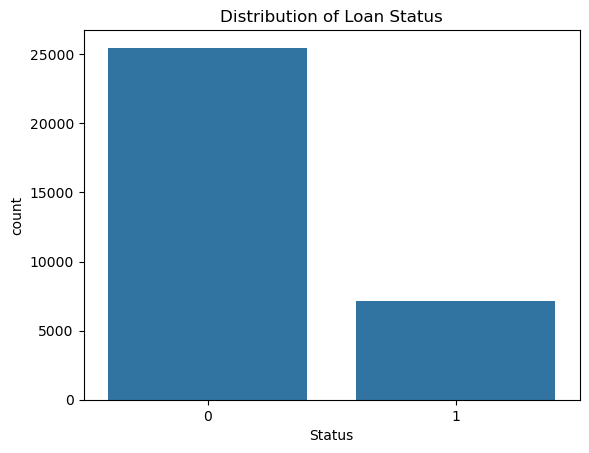

Status
0    78.181986
1    21.818014
Name: proportion, dtype: float64

In [21]:
sns.countplot(data=df, x="Status")
plt.title("Distribution of Loan Status")
plt.show()

df["Status"].value_counts(normalize=True) * 100

### Insight

The target variable is imbalanced, with more non-risky applicants than risky applicants. This means accuracy alone may not be enough to evaluate the model, because a model can achieve high accuracy by predicting the majority class more often. Therefore, precision, recall, F1-score, and confusion matrix should also be used during model evaluation.

### Numerical Feature Distributions

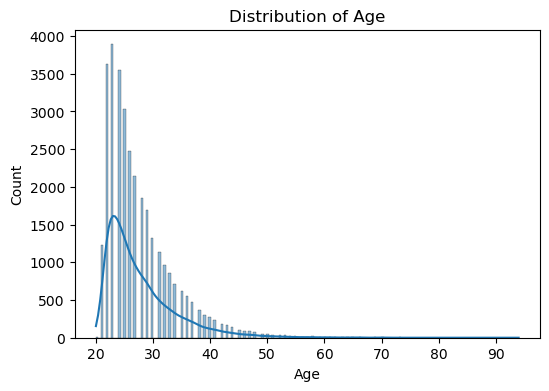

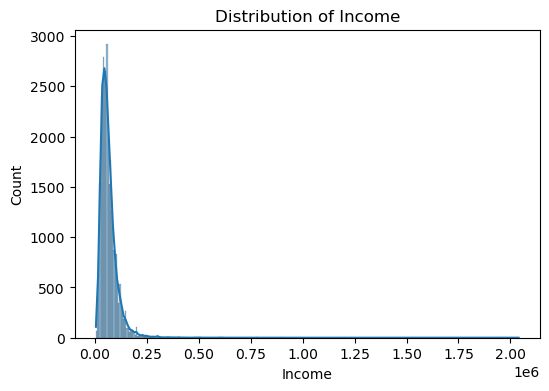

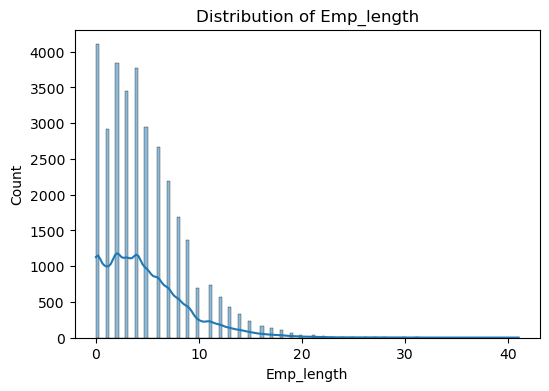

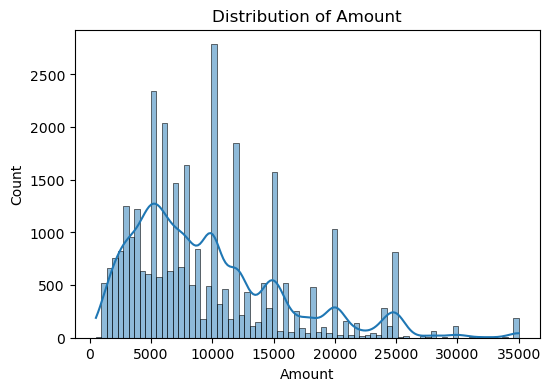

In [ ]:
num_cols = ["Age", "Income", "Emp_length", "Amount", "Rate", "Percent_income", "Cred_length"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### Insight

The numerical feature distributions show that `Income`, `Cred_length`, `Amount`, and `Percent_income` are right-skewed. `Income` shows the highest skewness, meaning most applicants have lower income while a small number of applicants have very high income. `Amount` and `Percent_income` also show right-skewed patterns, indicating the presence of applicants with relatively high loan amounts or high loan-to-income ratios.

Although `Cred_length` is also right-skewed, it represents credit history length and is kept in its original form because it is easier to interpret as a time-based feature. Extreme values in financial variables may represent real applicant behavior, so they are not removed blindly.

### Numerical Feature Outlier Detection

In [ ]:
for col in df.select_dtypes(include=['number']).drop('Status', axis=1).columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Insight

The boxplots show the presence of extreme values in several numerical features. Some of these extreme values may represent real applicant behavior and can provide useful information for credit risk prediction.

Only clearly unrealistic values, such as very high age or employment length, were handled during data cleaning. Other outliers were retained because removing them blindly could lead to loss of useful risk-related information.

### Categorical Feature Distributions

In [ ]:
cat_cols = ["Home", "Intent", "Default"]

for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

### Insight

The categorical distributions show how applicants are spread across home ownership type, loan purpose, and previous default history. These features are useful because they may capture applicant background and financial behavior that can influence credit risk.

### Numerical Features vs Status

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Status", y=col)
    plt.title(f"{col} vs Loan Status")
    plt.show()

### Insight

The comparison between numerical features and `Status` shows that variables such as `Rate`, `Percent_income`, and loan-related financial features differ between risky and non-risky applicants. This suggests that these variables may be useful predictors for identifying loan risk.

### Categorical Features vs Status

In [ ]:
for col in cat_cols:
    risk_rate = df.groupby(col)["Status"].mean().sort_values(ascending=False)  

    plt.figure(figsize=(7,4))
    sns.barplot(x=risk_rate.index, y=risk_rate.values)
    plt.title(f"Risk Rate by {col}")
    plt.ylabel("Risk Rate")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.show()


### Insight

The risk rate differs across categorical features such as `Home`, `Intent`, and `Default`. Applicants with previous default history show a higher risk rate, which indicates that past repayment behavior is an important factor in credit risk prediction.

### Correlation Analysis

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols + ["Status"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Insight

The correlation heatmap shows the linear relationship between numerical features and the target variable. Features such as `Rate` and `Percent_income` show a stronger relationship with `Status` compared to some other numerical variables. However, correlation only captures linear relationships, so it is used as supporting analysis rather than the only basis for feature importance.

### EDA Summary

The EDA showed that the dataset is imbalanced and that several numerical features contain skewness and extreme values. Risk patterns also differ across applicant groups such as home ownership, loan intent, and previous default history. These findings support the need to use proper evaluation metrics and compare multiple machine learning models.

## 6. Data Preprocessing & Feature Engineering
In this section, the cleaned dataset is prepared for machine learning. Feature engineering is performed, categorical features are encoded, numerical features are scaled, and the data is split into training and testing sets.

In [ ]:
df.head()

### Income Category Feature

In [ ]:
df["Income"].describe()

In [ ]:
df["Income_Category"] = pd.cut(
    df["Income"],
    bins=[0, 25000, 50000, 100000, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

df['Income_Category']

An income category feature was created to group applicants into different income levels. This can help the model capture income-based risk patterns more clearly.

### Outlier Treatment Decision

Extreme values in financial columns such as `Income`, `Amount`, `Rate`, and `Percent_income` were observed during EDA. These values were not removed because they may represent real applicant behavior and can provide useful information for credit risk prediction.

Only clearly unrealistic values, such as age above 100 and employment length above 60 years, were removed during data cleaning. Remaining financial outliers are retained and handled indirectly through feature scaling and model selection.

### Skewness Check and Log Transformation

In [ ]:
skewness = df[["Income", "Amount", "Rate", "Percent_income", "Cred_length"]].skew().sort_values(ascending=False)
skewness

Skewness was checked for numerical features before applying transformation. `Income` and `Amount` were log-transformed because they are money-related features with strong right-skewness. Although `Cred_length` and `Percent_income` also showed skewness, they were kept in their original form because they are directly interpretable and may provide meaningful credit-risk information.

In [ ]:
df["Income_log"] = np.log1p(df["Income"])
df["Amount_log"] = np.log1p(df["Amount"])

In [ ]:
# Then drop the original highly skewed columns:
df = df.drop(["Income", "Amount"], axis=1)

In [ ]:
df["Income_log"].skew()

In [ ]:
df["Amount_log"].skew()

Log transformation was applied to `Income` and `Amount` to reduce skewness and limit the effect of extreme values. The original columns were then dropped to avoid duplicate information.

### Train-Test Split

In [ ]:
X = df.drop('Status', axis=1)
y = df['Status'] 

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size= 0.2, random_state=42, stratify=y )
X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [ ]:
X_train.head()

In [ ]:
X_test.head()

### Encoding Categorical Features

In [ ]:
cat_cols = X_train.select_dtypes(include=["object", "category", "string"]).columns
cat_cols

In [ ]:
from sklearn.preprocessing import OneHotEncoder
one_hot = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")

encoded_train = one_hot.fit_transform(X_train[cat_cols])
encoded_test = one_hot.transform(X_test[cat_cols])

encoded_cols = one_hot.get_feature_names_out(cat_cols)

encoded_train_df = pd.DataFrame(
    encoded_train, columns=encoded_cols, index=X_train.index
)
encoded_test_df = pd.DataFrame(
    encoded_test, columns=encoded_cols, index=X_test.index
)

X_train = pd.concat(
    [X_train.drop(cat_cols, axis=1), encoded_train_df],
    axis=1
)

X_test = pd.concat(
    [X_test.drop(cat_cols, axis=1), encoded_test_df],
    axis=1
)

In [ ]:
X_train.head()

Categorical features were encoded using OneHotEncoder. The encoder was fitted only on the training data and then applied to the test data to avoid data leakage. The original categorical columns were replaced with encoded numerical columns.

### Feature Scaling

In [ ]:
scale_cols = [
    "Age", "Income_log", "Emp_length", "Amount_log",
    "Rate", "Percent_income", "Cred_length"
]
scale_cols

In [ ]:
scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])


X_train[scale_cols].head()

In [ ]:
X_test[scale_cols].head()

## 7. Model Building and Evaluation

In this section, multiple classification models are trained and evaluated. Since the dataset is imbalanced, models are compared using accuracy, precision, recall, F1-score, and confusion matrix rather than accuracy alone.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

### 1. Logistic Regression

In [ ]:
logist = LogisticRegression()
logist.fit(X_train, y_train)

y_pred_train_lr = logist.predict(X_train)
y_pred_test_lr = logist.predict(X_test)

print("Train Accuracy:",accuracy_score(y_train,y_pred_train_lr))
print("Test Accuracy:",accuracy_score(y_test,y_pred_test_lr))
print("\n confusion_matrix:\n",confusion_matrix(y_test, y_pred_test_lr))
print("\nclassification_report:\n",classification_report(y_test, y_pred_test_lr))


### 2. Decision Tree

In [ ]:
dtree = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dtree.fit(X_train, y_train)

y_pred_train_dt = dtree.predict(X_train)
y_pred_test_dt = dtree.predict(X_test)

print("Train Accuracy:",accuracy_score(y_train,y_pred_train_dt))
print("Test Accuracy:",accuracy_score(y_test,y_pred_test_dt))
print("\n confusion_matrix:\n",confusion_matrix(y_test, y_pred_test_dt))
print("\nclassification_report:\n",classification_report(y_test, y_pred_test_dt))

### Tuned Decision Tree

In [ ]:

from sklearn.model_selection import GridSearchCV

dtree = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

param_grid = {
    "max_depth": [3, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid,
    scoring="f1",
    n_jobs=-1,
    cv=5,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

grid_search.best_params_

In [ ]:
best_est = grid_search.best_estimator_

y_pred_train_dt_tuned = best_est.predict(X_train)
y_pred_test_dt_tuned = best_est.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train_dt_tuned))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_dt_tuned))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test_dt_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test_dt_tuned))

### Random Forest

In [ ]:
randf = RandomForestClassifier(n_estimators=500,n_jobs=1,class_weight="balanced",random_state=42)
randf.fit(X_train, y_train)

y_pred_train_rf = randf.predict(X_train)
y_pred_test_rf = randf.predict(X_test)

print("train_acc:",accuracy_score(y_train,y_pred_train_rf))
print("test_acc:",accuracy_score(y_test,y_pred_test_rf))

print("\n confusion_matrix:\n",confusion_matrix(y_test, y_pred_test_rf))
print("\nclassification_report:\n",classification_report(y_test, y_pred_test_rf))

### Tuned Random Forest

In [ ]:

rand = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rand,
    param_grid=param_grid,
    scoring="f1", 
    cv=5,
    n_jobs=-1,
    refit=True
)

rf_grid.fit(X_train, y_train)

rf_grid.best_params_
best_rf = rf_grid.best_estimator_
best_rf

In [ ]:
y_pred_train_rf_tuned = best_rf.predict(X_train)
y_pred_test_rf_tuned = best_rf.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train_rf_tuned))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_rf_tuned))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test_rf_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test_rf_tuned))

### KNN

In [ ]:

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_train_knn = knn.predict(X_train)
y_pred_test_knn = knn.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train_knn))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_knn))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test_knn))

### SVM

In [ ]:

svm = SVC(class_weight="balanced")

svm.fit(X_train, y_train)

y_pred_train_svm = svm.predict(X_train)
y_pred_test_svm = svm.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train_svm))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_svm))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test_svm))

### XGBoost

In [ ]:

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_train_xgb = xgb.predict(X_train)
y_pred_test_xgb = xgb.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train_xgb))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_xgb))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test_xgb))

### Model Comparison

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Tuned Decision Tree",
        "Random Forest",
        "Tuned Random Forest",
        "KNN",
        "SVM",
        "XGBoost"
    ],
    "Train Accuracy": [
        accuracy_score(y_train, y_pred_train_lr),
        accuracy_score(y_train, y_pred_train_dt),
        accuracy_score(y_train, y_pred_train_dt_tuned),
        accuracy_score(y_train, y_pred_train_rf),
        accuracy_score(y_train, y_pred_train_rf_tuned),
        accuracy_score(y_train, y_pred_train_knn),
        accuracy_score(y_train, y_pred_train_svm),
        accuracy_score(y_train, y_pred_train_xgb)
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_test_lr),
        accuracy_score(y_test, y_pred_test_dt),
        accuracy_score(y_test, y_pred_test_dt_tuned),
        accuracy_score(y_test, y_pred_test_rf),
        accuracy_score(y_test, y_pred_test_rf_tuned),
        accuracy_score(y_test, y_pred_test_knn),
        accuracy_score(y_test, y_pred_test_svm),
        accuracy_score(y_test, y_pred_test_xgb)
    ],
    "Class 1 Precision": [
        precision_score(y_test, y_pred_test_lr),
        precision_score(y_test, y_pred_test_dt),
        precision_score(y_test, y_pred_test_dt_tuned),
        precision_score(y_test, y_pred_test_rf),
        precision_score(y_test, y_pred_test_rf_tuned),
        precision_score(y_test, y_pred_test_knn),
        precision_score(y_test, y_pred_test_svm),
        precision_score(y_test, y_pred_test_xgb)
    ],
    "Class 1 Recall": [
        recall_score(y_test, y_pred_test_lr),
        recall_score(y_test, y_pred_test_dt),
        recall_score(y_test, y_pred_test_dt_tuned),
        recall_score(y_test, y_pred_test_rf),
        recall_score(y_test, y_pred_test_rf_tuned),
        recall_score(y_test, y_pred_test_knn),
        recall_score(y_test, y_pred_test_svm),
        recall_score(y_test, y_pred_test_xgb)
    ],
    "Class 1 F1-score": [
        f1_score(y_test, y_pred_test_lr),
        f1_score(y_test, y_pred_test_dt),
        f1_score(y_test, y_pred_test_dt_tuned),
        f1_score(y_test, y_pred_test_rf),
        f1_score(y_test, y_pred_test_rf_tuned),
        f1_score(y_test, y_pred_test_knn),
        f1_score(y_test, y_pred_test_svm),
        f1_score(y_test, y_pred_test_xgb)
    ]
})

model_comparison = model_comparison.round(4)
model_comparison.sort_values(by="Class 1 F1-score", ascending=False)

The comparison table summarizes the performance of all trained models.

## 8. Final Model Selection

XGBoost was selected as the final model because it achieved the best overall performance among all models. It produced the highest test accuracy and the highest F1-score for the risky class.

Although SVM achieved slightly higher recall for class 1, XGBoost provided a better balance between precision, recall, F1-score, and overall generalization. This balance is important in credit risk prediction because the model should identify risky applicants while also avoiding too many false positives.

The final XGBoost model achieved a test accuracy of 92.52%, class 1 precision of 0.94, class 1 recall of 0.71, and class 1 F1-score of 0.80.

### Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Important Features - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Feature Importance Insight

The feature importance plot shows that home ownership, `Percent_income`, interest rate, loan intent, and income-related features are among the most important predictors of credit risk. This suggests that both an applicant’s financial capacity and background characteristics play an important role in identifying risky applicants.

## 9. Business Interpretation

In this project, class 1 represents risky applicants. The most important error is a false negative, where a risky applicant is incorrectly predicted as non-risky. This type of mistake can lead to financial loss for lenders.

The final XGBoost model achieved a class 1 recall of 0.71, meaning it correctly identified 71% of risky applicants. It also achieved a class 1 F1-score of 0.80, showing a good balance between detecting risky applicants and maintaining prediction reliability.

This model can support financial institutions by helping them identify high-risk loan applicants before loan approval.

## 10. Conclusion

This project developed a machine learning model to predict credit risk among loan applicants. The dataset was cleaned by removing unrealistic values, handling missing values, and removing unnecessary identifier columns.

EDA showed that the dataset is imbalanced and that risk patterns differ across numerical and categorical features. Several machine learning models were trained and compared, including Logistic Regression, Decision Tree, Random Forest, KNN, SVM, and XGBoost.

Among all models, XGBoost achieved the best overall performance with a test accuracy of 92.52% and a class 1 F1-score of 0.80. Therefore, XGBoost was selected as the final model for credit risk prediction.

## 11. Prediction on New Applicant Data

In this section, the final trained XGBoost model is tested on a new applicant record. The same preprocessing steps used during training are applied to the new input before making a prediction.

In [ ]:
# New applicant data
new_applicant = pd.DataFrame({
    "Age": [30],
    "Income": [60000],
    "Home": ["RENT"],
    "Emp_length": [5],
    "Intent": ["EDUCATION"],
    "Amount": [10000],
    "Rate": [12.5],
    "Percent_income": [0.17],
    "Default": ["N"],
    "Cred_length": [4]
})


# Create Income_Category
new_applicant["Income_Category"] = pd.cut(
    new_applicant["Income"],
    bins=[0, 25000, 50000, 100000, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

# Apply log transformation
new_applicant["Income_log"] = np.log1p(new_applicant["Income"])
new_applicant["Amount_log"] = np.log1p(new_applicant["Amount"])

# Drop original transformed columns
new_applicant = new_applicant.drop(["Income", "Amount"], axis=1)


In [ ]:
# Encode categorical columns using fitted OneHotEncoder
new_encoded = one_hot.transform(new_applicant[cat_cols])

new_encoded_df = pd.DataFrame(
    new_encoded,
    columns=encoded_cols,
    index=new_applicant.index
)

new_applicant = pd.concat(
    [new_applicant.drop(cat_cols, axis=1), new_encoded_df],
    axis=1
)

# Match training column order
new_applicant = new_applicant.reindex(columns=X_train.columns, fill_value=0)

# Apply scaling using fitted scaler
new_applicant[scale_cols] = scaler.transform(new_applicant[scale_cols])


In [ ]:
# Predict using final XGBoost model
prediction = xgb.predict(new_applicant)
prediction_probability = xgb.predict_proba(new_applicant)

non_risky_probability = prediction_probability[0][0]
risky_probability = prediction_probability[0][1]

print("Prediction:", prediction[0])
print(f"Non-Risky Probability: {non_risky_probability:.2%}")
print(f"Risky Probability: {risky_probability:.2%}")

if prediction[0] == 1:
    print("Result: Risky Applicant")
else:
    print("Result: Non-Risky Applicant")

## 12. Saving Model and Preprocessing Objects

The final XGBoost model and preprocessing objects are saved using pickle so they can be reused later for deployment.

In [ ]:
import pickle

deployment_objects = {
    "model": xgb,
    "one_hot": one_hot,
    "scaler": scaler,
    "cat_cols": cat_cols,
    "encoded_cols": encoded_cols,
    "scale_cols": scale_cols,
    "train_columns": X_train.columns
}

with open("credit_risk_model.pkl", "wb") as file:
    pickle.dump(deployment_objects, file)